In [1]:
import numpy as np
import torch
from matplotlib import pyplot as plt

def get_device(verbose: bool = True) -> torch.device:
    """
    Auto-pick the best available device:
      - CUDA if available (NVIDIA GPU)
      - else MPS if available (Apple Silicon GPU)
      - else CPU
    """
    if torch.cuda.is_available():
        device = torch.device("cuda")
        name = torch.cuda.get_device_name(device)
    elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
        device = torch.device("mps")
        name = "Apple MPS"
    else:
        device = torch.device("cpu")
        name = "CPU"

    if verbose:
        print(f"[PyTorch] Using device: {device} ({name})")
    return device

In [2]:
from dataclasses import dataclass

@dataclass
class LatticeModel:
    w: torch.Tensor       # weights
    c: torch.Tensor       # discrete velocities
    opposites: torch.Tensor
    theta: torch.Tensor   # lattice speed of sound squared
    D: int                # number of dimensions
    Q: int                # number of directions
    
def feq_2nd_order(rho, ux, uy, lattice_model: LatticeModel):
    """
    Compute equilibrium distribution function (f^{eq}_i) approximated to 2nd-order Taylor expansion about u=0
    
    Inputs:
    - rho: (Ny, Nx) density
    - ux, uy: (Ny, Nx) velocity components
    - w: (Q,) weights
    - c: (Q,2) discrete velocities
    - theta: cs^2 where cs^2 is lattice speed of sound squared
    
    Returns:
    - feq: (Ny, Nx, Q) equilibrium distributions
    """

    Ny, Nx = rho.shape
    Q = lattice_model.Q
    # shape (Q,1,1) for broadcasting over (Ny,Nx)
    cx = lattice_model.c[:,0].float().view(Q, 1, 1).to(rho.device)
    cy = lattice_model.c[:,1].float().view(Q, 1, 1).to(rho.device)
    w = lattice_model.w.view(Q, 1, 1).to(rho.device)
    theta = lattice_model.theta

    u_sq = ux**2 + uy**2 # (Ny, Nx)
    cu = cx*ux + cy*uy   # (Ny, Nx, Q)
    
    # equilibrium distribution # (Q, Ny, Nx)
    feq = w * rho.unsqueeze(0) * (
        1 + cu/theta + 0.5*(cu**2)/(theta**2) - 0.5*(u_sq)/theta
    )                    
    
    # permute to (Ny, Nx, Q)
    feq = feq.permute(1, 2, 0).contiguous()
    
    return feq
    

def macroscopic(f, lattice_model: LatticeModel):
    """
    Compute macroscopic density and velocity from distribution function f.
    
    Inputs:
    - f: (Ny, Nx, Q) distribution function
    - lattice_model: LatticeModel object
    
    Returns:
    - rho: (Ny, Nx)
    - ux:  (Ny, Nx)
    - uy:  (Ny, Nx)
    """
    # Sum over directions to get density
    rho = f.sum(dim=-1)  # (Ny, Nx)

    # Extract velocity components
    cx = lattice_model.c[:,0].float().to(f.device)  # (Q,)
    cy = lattice_model.c[:,1].float().to(f.device)  # (Q,)

    # Compute momentum: sum_i f_i * c_i
    ux = (f * cx.view(1,1,-1)).sum(dim=-1) / rho
    uy = (f * cy.view(1,1,-1)).sum(dim=-1) / rho

    return rho, ux, uy

def collision(f, feq, tau):
    """
    Collision step: Move from current equilibrium state feq to the next f.
    
    Inputs:
    - f: (Ny, Nx, Q) pre-collision distribution
    - f_eq: (Ny, Nx, Q) equlibrium distribution
    - lattice_model: LatticeModel object
    
    Returns:
    - f_star: (Ny, Nx, Q) post-collision distribution
    """
    
    f_star = f - (1/(tau + 0.5)) * (f - feq)
    return f_star

def streaming(f, lattice_model: LatticeModel):
    """
    Streaming step: propagate f_star along its discrete velocities.
    
    Inputs:
    - f: (Ny, Nx, Q) distribution at t to be streamed
    - lattice_model: LatticeModel object
    
    Returns:
    - f_next: (Ny, Nx, Q) distribution at (t + dt) after streaming
    """
    Ny, Nx, Q = f.shape
    f_next = torch.empty_like(f)
    
    # Get discrete velocities
    cx = lattice_model.c[:,0].int()
    cy = lattice_model.c[:,1].int()
    
    # Loop over directions (small, only Q iterations)
    for i in range(Q):
        f_next[:,:,i] = torch.roll(f[:,:,i], shifts=(cy[i], cx[i]), dims=(0,1))
    
    return f_next


def bounce_back_bc_on_obstacles(f, f_star, obstacles, lattice_model: LatticeModel):
    """
    General bounce-back on obstacle locations.

    Inputs:
    - f: (Ny, Nx, Q) distribution function after streaming
    - f_star: (Ny, Nx, Q) distribution function before streaming
    - obstacle: (Ny, Nx) boolean mask (True where obstacle is present)
    - lattice_model: contains .opposites (Q,) array

    Updates f in-place.
    """

    # Bounce-back: replace distributions at obstacle nodes
    f[obstacles] = f_star[obstacles][:, lattice_model.opposites]

    return f



In [2]:
rho = 1000 # density, kg/m3
g = 9.8 # gravity m/s2
D = 0.01 # 1cm
mu = 1e-3 # dynamic viscosity

rho * g * (D**2) / (32 * mu)


30.625000000000004

In [3]:
device = get_device()

[PyTorch] Using device: mps (Apple MPS)


In [4]:
# Instantiate D2Q9 model
w = torch.tensor([4/9] + 4*[1/9] + 4*[1/36], dtype=torch.float32, device=device)
c = torch.tensor([
    [ 0,  0],                               # 1 central direction
    [ 1,  0], [ 0,  1], [-1,  0], [ 0, -1], # 4 cardinal directions
    [ 1,  1], [-1,  1], [-1, -1], [ 1, -1]  # 4 diagonal directions 
], dtype=torch.int32)
theta = torch.tensor(1/3, dtype=torch.float32, device=device)
# To be checked: Why when defining theta as python floats (i.e. theta = 1/3) 
# it gives floating point precission error that fails to conserve mass
D,Q = 2,9
opposites = torch.tensor([0,3,4,1,2,7,8,5,6], dtype=torch.long, device=device)

D2Q9 = LatticeModel(w=w, c=c, theta=theta, D=D, Q=Q, opposites=opposites)

In [5]:
# Macroscopic Physical variables
L, W = 0.01, 0.01 # lenght x width of space, in m
d = 0.01 # characteristic length, in m (e.g obstacle size)
RHO = 1e3 # fluid density in kg/m3
U_phys = 0.04 # velocity in m/s
mu_phys = 1e-3 # dynamic viscosity
nu_phys = mu_phys / RHO # kinematic viscosity
g = 9.8 # gravity m/s2
Re = U_phys * W / nu_phys
print(f'Reynolds Number: {Re:.2f}') 

Reynolds Number: 400.00


In [6]:
# -----------------------------
# Space resolution
# -----------------------------
dx = 2e-5   # lattice spacing (m) -> finer grid
Nx, Ny = int(np.ceil(L/dx)), int(np.ceil(W/dx))
print(f'Lattice size dx: {dx} | [{Nx}, {Ny}] grids')

# -----------------------------
# Velocity scaling
# -----------------------------
u_lattice = 0.08   # lattice velocity (reduce Mach)
Mach = u_lattice / torch.sqrt(theta)
print(f"Mach Number = {Mach:.3f}")

# -----------------------------
# Time resolution
# -----------------------------
dt = u_lattice * dx / U_phys
tau = nu_phys * dt / (theta * dx**2)
nu_lattice = theta * tau
g_lattice = g * dt**2 / dx
rho_lattice = 1

print(f"Δt = {dt:.3e} s")
print(f"τ = {tau:.4f}")
print(f"ν_lattice = {nu_lattice:.4e}")
print(f"g_lattice = {g_lattice:.4e}")

Lattice size dx: 2e-05 | [500, 500] grids
Mach Number = 0.139
Δt = 4.000e-05 s
τ = 0.3000
ν_lattice = 1.0000e-01
g_lattice = 7.8400e-04


In [7]:
# --- Obstacles initialisation ---
obstacles = torch.zeros((Ny, Nx), dtype=torch.bool, device=device)
obstacles[0, :] = True # top walls of the channel
obstacles[Ny-1, :] = True # bottom walls of the channel

# --- State variables ---
rho = torch.full((Ny, Nx), rho_lattice, dtype=torch.float32, device=device)
ux  = torch.full((Ny, Nx), u_lattice, dtype=torch.float32, device=device)  # flow in x
uy  = torch.zeros((Ny, Nx), dtype=torch.float32, device=device)            # no flow in y

# --- Initialise distribution function as equilibrium distribution ---
f = feq_2nd_order(rho, ux, uy, D2Q9)

# check mass conservation
assert torch.allclose(rho.sum(), f.sum())

In [8]:
# --- Main LBM timestep loop ---
import time

u_sample = []
t_sample = []
t, t_max = 0, 25000

print(f'Starting time step loop. 1000 loops = {dt * 1000:.2f} physical second')
start = time.time()

# --- time loop ---
while t < t_max:
    rho, ux, uy = macroscopic(f, D2Q9)
    
    if t % 1000 == 0 or (t <= 1000 and t % 10 == 0):
        t_sample.append(t)
        u_sample.append(ux[:,50].detach().clone().cpu().numpy())
        
    feq = feq_2nd_order(rho, ux, uy, D2Q9)
    
    # collision
    f_star = collision(f, feq, tau)
    
    # streaming
    f_next = streaming(f_star, D2Q9)
    
    # bounce back on obstacles
    bounce_back_bc_on_obstacles(f_next, f_star, obstacles, D2Q9)
    f = f_next

    # check mass conservation and raise errors if not satisfied
    assert torch.allclose(rho.sum(), f.sum())
        
    t += 1  
duration = (time.time() - start)

print(f'Finish after {t} steps, equals to {t * dt:.3f} physical seconds')
print(f'Execution duration: {duration:.2f}s')

Starting time step loop. 1000 loops = 0.04 physical second
Finish after 25000 steps, equals to 1.000 physical seconds
Execution duration: 266.39s


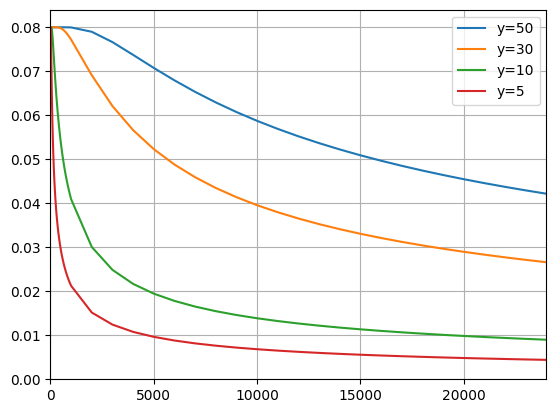

In [9]:
u_sample = np.array(u_sample)
t_sample = np.array(t_sample)
u_sample.shape

plt.plot(t_sample, u_sample[:, 50], label='y=50')
plt.plot(t_sample, u_sample[:, 30], label='y=30')
plt.plot(t_sample, u_sample[:, 10], label='y=10')
plt.plot(t_sample, u_sample[:, 5], label='y=5')
plt.legend()
plt.xlim([0,t_sample.max()])
plt.ylim([0, u_lattice * 1.05])
plt.grid()
plt.show()

# Test

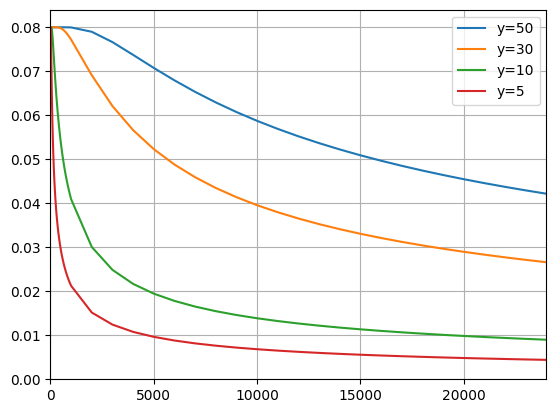

In [10]:
u_sample = np.array(u_sample)
t_sample = np.array(t_sample)
u_sample.shape

plt.plot(t_sample, u_sample[:, 50], label='y=50')
plt.plot(t_sample, u_sample[:, 30], label='y=30')
plt.plot(t_sample, u_sample[:, 10], label='y=10')
plt.plot(t_sample, u_sample[:, 5], label='y=5')
plt.legend()
plt.xlim([0,t_sample.max()])
plt.ylim([0, u_lattice * 1.05])
plt.grid()
plt.show()